[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6-pm/05_inspect_latent_motion.ipynb)

# 05. Inspect the final staged representation

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

## The question this notebook answers

Notebook 04 finished with healthy-looking training curves. This notebook asks the harder question: **what does the learned representation actually look like, and does its geometry support the five-condition story the training objective was pushing for?**

## The one distinction that matters most in this notebook

There are two completely different claims a reader can take away from a representation audit, and conflating them is the single easiest mistake to make with this project. Keep them apart from the start.

| Claim | What would count as evidence | Verdict here |
|---|---|---|
| **The run did not collapse.** The encoder maps different sequences to different vectors instead of squashing everything onto one point. | Nonzero feature spread, mean pairwise cosine away from 1, nonzero within-condition distance, finite embeddings. | **Supported.** |
| **The conditions are separable.** The five condition groups occupy distinguishable regions of the representation. | Between-centroid distances that are large relative to within-condition spread, and a silhouette clearly above zero. | **Not supported.** |

Non-collapse is a floor. It says the encoder is doing *something*. It says nothing whatsoever about *what*. A run can pass every collapse check and still produce a representation in which the five conditions are hopelessly intermingled, and that is exactly what we find below: the canonical 96-sequence cosine silhouette is **0.054**, and the two closest condition centroids are only **0.026** apart while the average within-condition spread is **0.104**. The closest classes are four times closer to each other than a typical sequence is to its own centroid.

So a healthy training curve and a useful representation are different things. Notebook 04's losses fell, its feature spread stayed away from zero, and its margin penalty was being optimized the whole time. None of that was wrong, and none of it implied the geometry below. Optimization progress is a statement about the objective; separability is a statement about the data and the cohort.

## What you need before you start

**Run notebook 04 first.** This notebook requires a completed final curriculum checkpoint. It selects `sjepa_curriculum_final_augmented.pt` when `SJEPA_INCLUDE_AUGMENTED_NORMAL=1`, otherwise `sjepa_curriculum_final.pt`, and it never silently falls back to a different cohort or to the legacy normal-only model. `SJEPA_INSPECT_CHECKPOINT` overrides the filename explicitly when you need a specific artifact.

## What it produces

- `curriculum_representation_geometry.csv`, the one-row geometry summary including the silhouette and the minimum between-centroid distance.
- `curriculum_centroid_distances.csv`, the full five-by-five centroid cosine-distance matrix.
- Figures for the retrieval pose strip and the normal-reference distance distribution.

## An unavoidable property of every number below

All of it is **transductive**: the encoder that produces these embeddings was trained on these very sequences, and from Stage 1 onward it was trained with their condition labels. Nothing here is a held-out measurement. When a number looks good, that is the first explanation to rule out.

Also note that the **source video, not the sequence, is the independent unit of evidence.** These 96 canonical sequences come from only 18 source videos, and normal comes from a single one. Two sequences from one upload can resemble each other because of framing, person identity, or background rather than gait.

## The nine steps

1. Point the notebook at the data and choose the run mode.
2. Restate the shared definitions so this notebook stands alone.
3. Load the completed curriculum checkpoint and audit its lineage.
4. Load the 96 canonical sequences and check their landmark coverage.
5. Diagnostic 1: does the predictor match the teacher at hidden tokens?
6. Pool one fixed-length vector per sequence.
7. Diagnostic 2: measure the condition geometry, and read it honestly.
8. Diagnostic 3: nearest-sequence retrieval, and its source-video trap.
9. Diagnostic 4: distance from the normal reference.


## Step 1 of 9: point the notebook at the data and choose the run mode

**What we are about to do.** Resolve the repository root, load `.env`, decide between `smoke` and `real` mode, and locate the artifact directory that notebook 04 wrote into.

**Why this comes first.** The checkpoint, the pose cache, and every output of this notebook all live under `ARTIFACT_DIR`, and `ARTIFACT_DIR` depends on the mode. Resolving the mode before loading anything is what prevents a smoke run from reading real artifacts or overwriting them.

**What to look at in the output.** `mode:` must read `real` for a result you intend to cite, and `artifacts:` must be the same directory notebook 04 reported. If the two disagree, this notebook is inspecting a different run than you think.

**What we may conclude.** Only that the environment matches notebook 04's. The figure in the next cell previews the four diagnostics we are about to run.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/dev/alexpose/data/gavd
YouTube cache: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/youtube
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real


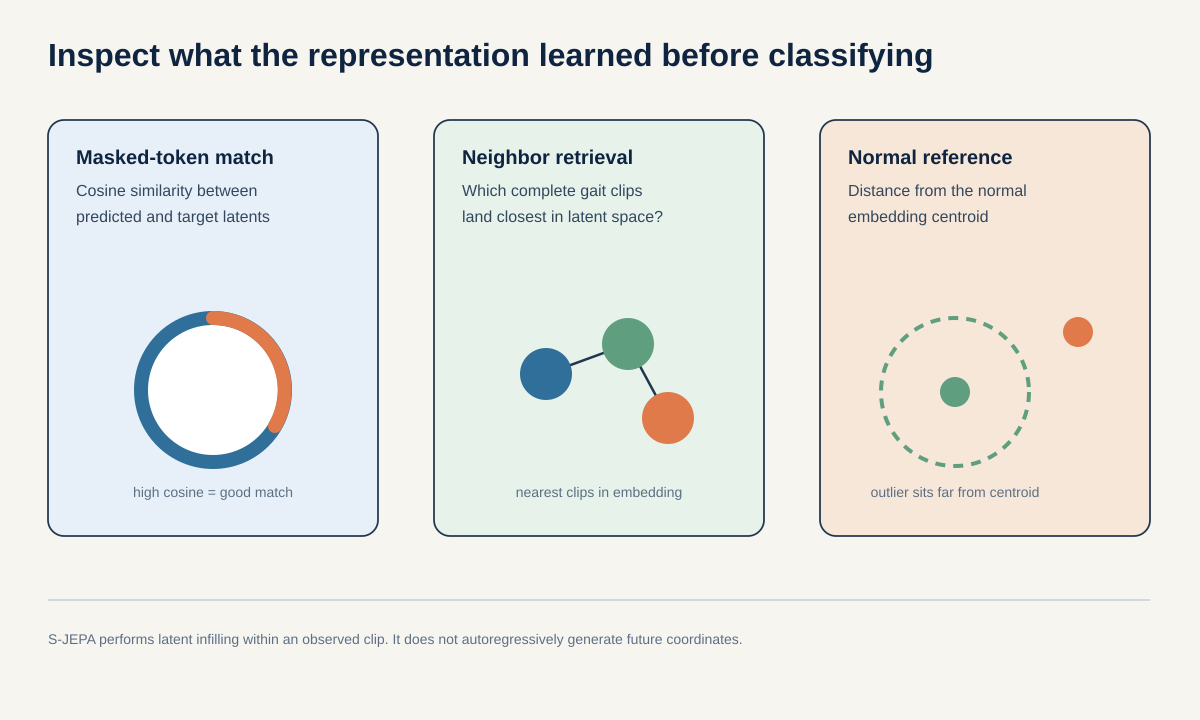

In [2]:
show_tutorial_svg("07_latent_inspection.svg")


## Step 2 of 9: restate the shared definitions

**What we are about to do.** Run seven definition cells that are deliberate copies of notebook 04's. They introduce no results.

**Why duplicate them.** So this notebook can be opened and run on its own, in Colab or locally, without importing from a sibling notebook. The duplication is intentional and the definitions must stay identical, because a divergence would silently change what the embeddings mean.

The definitions, in order: the 33 landmark names and the 12-index target whitelist; the locked cohort census and the five-stage curriculum; the synthetic smoke fixtures, which are code-path tests with no pathophysiological meaning; the preprocessing chain that produces a `[64, 33, 3]` tensor plus a validity mask; the uniform mask sampler, whose configured 0.60 is applied to the **smallest** eligible-token count in the batch rather than to each sample separately; the encoder, predictor, and EMA-teacher model classes; and the pose-cache loader.

One reminder about the pooling that follows in Step 6: a joint-time patch counts as valid only when **all four** of its source frames are valid for that joint, so the zero sentinels written in place of missing coordinates never enter a mean or a standard deviation directly.

**What we may conclude.** Nothing empirical yet.


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [4]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


In [8]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


In [9]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored_condition = str(data["condition"].item())
            if stored_condition != condition:
                raise ValueError(
                    f"Pose condition {stored_condition} does not match folder {condition}"
                )
            if len(data["frame_numbers"]) != len(sequence):
                raise ValueError(f"Frame and pose lengths differ in {path}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "extraction_version": str(data["extraction_version"].item()),
                "pose_model_sha256": str(data["pose_model_sha256"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, smoke_per_condition=10, frames=64):
    if MODE == "smoke":
        records = synthetic_corpus(
            conditions=conditions,
            n_per_condition=smoke_per_condition,
            frames=frames,
        )
        print(f"Explicit smoke corpus: {len(records)} synthetic sequences")
        return records
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [condition for condition in conditions if counts.get(condition, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. "
            "Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


## Step 3 of 9: load the completed curriculum checkpoint and audit its lineage

**What we are about to do.** Select the final checkpoint, load it, verify it against a list of hard requirements, and rebuild the model from its recorded configuration.

**Why audit rather than just load.** A checkpoint file with the right name can still be the wrong artifact: the normal-only Stage 0 model, a smoke-mode run, a run with a different mask whitelist, or a cohort that does not match the flag currently set in `.env`. Every one of those would produce plausible-looking embeddings and quietly invalidate the rest of the notebook. So the cell refuses to continue on any of the following: a mode that does not match, a mask list other than the 12-point mapping whitelist, a curriculum that is not marked complete, a stage order other than `normal, parkinsons, stroke, myopathic, cerebralpalsy`, or a cohort that disagrees with `SJEPA_INCLUDE_AUGMENTED_NORMAL`. The default is the final Stage 4 model for the cohort selected in `.env`, not the normal-only checkpoint.

**What to look at in the output.** Six lines, and the fingerprints are the ones that matter:

- `checkpoint: sjepa_curriculum_final_augmented.pt` and `augmented normal in checkpoint: True`, so this is the augmented-cohort run.
- `checkpoint fingerprint: ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4`. This must equal the final fingerprint notebook 04 printed. If it does not, the two notebooks are describing different runs and no comparison between them is valid.
- `parent fingerprint: 269c400ef0f16f64295dc52fb56c4205a84b1230d1048576254176297f3f0558`, which is the Stage 3 fingerprint, so the parent chain is intact.
- `completed stages:` lists all five in order.
- `label-aware after Stage 0: True`. Remember what that flag means: from Stage 1 onward the encoder was trained with a term that reads condition labels. Every geometry number below is therefore measured on a representation that was **explicitly optimized** to separate these labels on these rows.

**What we may conclude.** That we are inspecting the intended artifact, and that its lineage is verifiable rather than assumed.

**What we may not conclude.** Nothing about representation quality. The audit checks provenance, not merit.


In [10]:
TRUTHY = {"1", "true", "yes", "on"}
include_augmented_normal = os.getenv(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in TRUTHY
explicit_checkpoint = os.getenv("SJEPA_INSPECT_CHECKPOINT", "").strip()
if explicit_checkpoint:
    checkpoint_path = Path(explicit_checkpoint).expanduser()
    if not checkpoint_path.is_absolute():
        checkpoint_path = ARTIFACT_DIR / checkpoint_path
    checkpoint_source = "SJEPA_INSPECT_CHECKPOINT"
else:
    checkpoint_name = (
        "sjepa_curriculum_final_augmented.pt"
        if include_augmented_normal
        else "sjepa_curriculum_final.pt"
    )
    checkpoint_path = ARTIFACT_DIR / checkpoint_name
    checkpoint_source = "SJEPA_INCLUDE_AUGMENTED_NORMAL"
if not checkpoint_path.is_file():
    available = sorted(path.name for path in ARTIFACT_DIR.glob("sjepa_curriculum_final*.pt"))
    raise FileNotFoundError(
        f"Expected final checkpoint {checkpoint_path} (selected by {checkpoint_source}). "
        f"Available final checkpoints: {available or 'none'}. "
        f"Run every stage of notebook 04 in {MODE} mode with the same "
        "SJEPA_INCLUDE_AUGMENTED_NORMAL setting, or set "
        "SJEPA_INSPECT_CHECKPOINT explicitly."
    )
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
if checkpoint["mode"] != MODE:
    raise ValueError(f"Checkpoint mode {checkpoint['mode']} does not match {MODE}")
if checkpoint["mask_keypoints"] != MASK_KEYPOINTS:
    raise ValueError("Checkpoint mask set does not match the required 12-point whitelist")
expected_conditions = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
if not checkpoint.get("curriculum_complete", False):
    raise ValueError("Checkpoint is not the completed progressive curriculum")
if checkpoint.get("conditions_seen") != expected_conditions:
    raise ValueError(f"Unexpected curriculum order: {checkpoint.get('conditions_seen')}")
checkpoint_has_augmented_normal = "augmented_normal" in checkpoint.get("cohorts", [])
if not explicit_checkpoint and checkpoint_has_augmented_normal != include_augmented_normal:
    raise ValueError(
        "Checkpoint cohort does not match SJEPA_INCLUDE_AUGMENTED_NORMAL; "
        "rerun notebook 04 with the current setting or use an explicit checkpoint."
    )
model = SJEPAGait(**checkpoint["config"])
model.load_state_dict(checkpoint["model_state"])
model.eval()
config = checkpoint["config"]
FRAMES = config["frames"]
SEGMENT_LENGTH = config["segment_length"]
print("checkpoint:", checkpoint_path.name)
print("checkpoint selection:", checkpoint_source)
print("augmented normal in checkpoint:", checkpoint_has_augmented_normal)
print("checkpoint fingerprint:", checkpoint["dataset_fingerprint"])
print("parent fingerprint:", checkpoint.get("parent_fingerprint"))
print("completed stages:", [stage["name"] for stage in checkpoint["completed_stages"]])
print("label-aware after Stage 0:", checkpoint.get("label_aware_after_stage0"))


checkpoint: sjepa_curriculum_final_augmented.pt
checkpoint selection: SJEPA_INCLUDE_AUGMENTED_NORMAL
augmented normal in checkpoint: True
checkpoint fingerprint: ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4
parent fingerprint: 269c400ef0f16f64295dc52fb56c4205a84b1230d1048576254176297f3f0558
completed stages: ['normal_only', 'add_parkinsons', 'add_stroke', 'add_myopathic', 'add_cerebralpalsy']
label-aware after Stage 0: True


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_76990/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_76990/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## Step 4 of 9: load the 96 canonical sequences

**What we are about to do.** Load every canonical condition folder, preprocess each sequence to the checkpoint's own frame count, and gate on landmark coverage.

**Why the canonical 96 and not the 159 the encoder trained on.** This notebook measures geometry on the canonical GAVD cohort, so the numbers are comparable with notebook 06's evaluation lanes and with the wider project's shared 96-sequence, 18-video reference cohort. The encoder itself was trained on 159 rows, the extra 63 being the augmented normal windows. Keep the two counts distinct: **trained on 159, geometry measured on 96.**

**Why the target encoder and not the view encoder.** All downstream embeddings come from the complete, unmasked EMA target encoder. The predictor's outputs are used only in Step 5 and nowhere else. The target encoder is the stable, gradient-free average of the view encoder, so it is the sensible thing to freeze and read out.

**What to look at in the output.** `Real pose corpus: 96 sequences`, then a per-condition coverage table, then the class census. The census must read normal 12, Parkinson's 9, stroke 12, myopathic 47, cerebral palsy 16. The coverage table's `min` column is the one to inspect: stroke has the worst single sequence at 0.578 observed authorized landmarks, against a mean of 0.943, while cerebral palsy, myopathic, and normal all average above 0.99. The gate is `GAVD_MIN_NEURO_COVERAGE`, default 0.50, and nothing fell below it.

**What we may conclude.** That the cohort is the locked 96 and that no sequence is so sparsely tracked that its embedding would be mostly sentinel-driven.

**What we may not conclude.** That coverage is uniform. Stroke is measurably the worst-tracked condition, which is worth remembering later: any apparent stroke signal deserves a check against detector behaviour rather than being read as gait. Notebook 06 makes that check explicit with a missingness-only control.


In [11]:
records = load_records_for_mode(
    conditions=CONDITIONS,
    smoke_per_condition=8,
    frames=FRAMES,
)
prepared = [
    prepare_sequence(record["sequence"], frames=FRAMES)
    for record in records
]
all_xyz = np.stack([item[0] for item in prepared])
all_valid = np.stack([item[1] for item in prepared])
labels = np.asarray([record["condition"] for record in records])
sequence_ids = np.asarray([record["sequence_id"] for record in records])
video_ids = np.asarray([record["video_id"] for record in records])
min_coverage = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
coverage_report = pd.DataFrame({
    "condition": labels,
    "sequence_id": sequence_ids,
    "neurologic_observed_fraction": all_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2)),
})
display(coverage_report.groupby("condition")["neurologic_observed_fraction"].agg(["min", "mean"]))
if (coverage_report["neurologic_observed_fraction"] < min_coverage).any():
    raise ValueError("At least one sequence fails the neurologic coverage threshold")
pd.Series(labels).value_counts().reindex(CONDITIONS)


Real pose corpus: 96 sequences


,min,mean
condition,,
cerebralpalsy,0.980469,0.998291
myopathic,0.951823,0.993628
normal,0.925781,0.992296
parkinsons,0.846354,0.971644
stroke,0.578125,0.942600


normal           12
parkinsons        9
stroke           12
myopathic        47
cerebralpalsy    16
Name: count, dtype: int64

## Step 5 of 9, Diagnostic 1: does the predictor match the teacher at hidden tokens?

**What we are about to do.** Take four sequences, mask their eligible tokens with the same sampler used in training, run the JEPA forward pass, and measure the cosine similarity between each predicted feature vector and the teacher's feature vector for the same hidden token.

**Why this diagnostic comes first.** It is the closest thing to a direct check that the pretext task was learned at all. If the predictor cannot match the teacher above chance, nothing further in the notebook is interpretable, because the objective that shaped the representation was never satisfied.

**What this measures, and what it does not.** It measures agreement in **latent** space at permitted hidden tokens. It does **not** decode a future skeleton, and it does not reconstruct coordinates. A high cosine means the predictor learned the teacher's feature geometry, not that anyone could recover the missing joints as pixels or positions.

Note that the view passed in here is built with `max_degrees=0.0` and `translate=0.0`, so the geometric augmentation is switched off. This isolates the masking effect from the augmentation effect.

**What to look at in the output.** Three numbers: the mean token cosine, its standard deviation, and how many hidden tokens each sequence contributed.


In [12]:
batch_xyz = torch.tensor(all_xyz[:4], dtype=torch.float32)
batch_valid = all_valid[:4]
segments = FRAMES // SEGMENT_LENGTH
valid_patch = batch_valid.reshape(
    len(batch_valid), segments, SEGMENT_LENGTH, 33
).all(axis=2)
mask_np = uniform_neurologic_mask(valid_patch, 0.60, seed=101)
target_mask = torch.tensor(mask_np)
with torch.no_grad():
    predicted, target = model(
        geometric_view(
            batch_xyz,
            max_degrees=0.0,
            translate=0.0,
            flip_probability=0.0,
        ),
        batch_xyz,
        target_mask,
    )
    similarity = torch.nn.functional.cosine_similarity(
        predicted,
        target,
        dim=-1,
    )
print("mean token cosine:", float(similarity.mean()))
print("token cosine std:", float(similarity.std(unbiased=False)))
print("tokens per sequence:", similarity.shape[1])


mean token cosine: 0.5527895092964172
token cosine std: 0.10895916074514389
tokens per sequence: 114


**What the output shows.** In the completed real run the mean token cosine is **0.553**, with a standard deviation of **0.109** across 114 hidden tokens per sequence. The tight standard deviation matters as much as the mean: agreement is broadly similar across tokens rather than being carried by a handful of easy ones.

**What we may conclude.** The pretext task was genuinely learned. A mean of 0.553 in a 96-dimensional feature space is far from the near-zero cosine an untrained predictor would give, so the JEPA objective in notebook 04 did what it was asked to do.

**What we may not conclude.** That the features are useful. This number is computed from the same objective the model was trained on, so a good score here is close to self-fulfilling. It is a sanity check, not a result. If you are running a short smoke profile instead, expect a much lower value, and do not compare it with the real run.

In a longer run, track this metric alongside feature spread rather than in isolation, and do not tune anything on notebook 06's classifier test rows.


## Step 6 of 9: pool one fixed-length vector per sequence

**What we are about to do.** Turn each sequence's variable set of valid joint-time tokens into one fixed-length vector, so that the geometry, retrieval, and classifier steps all operate on a matrix with one row per sequence.

**Why pooling has to be an explicit, documented choice.** The S-JEPA paper does not specify its downstream pooling, so this is a design decision of ours and not an inherited standard. Different pooling would give different geometry numbers, which is exactly why it is written down here rather than buried in code. This tutorial concatenates four blocks:

1. mean over every joint-time token;
2. standard deviation over every joint-time token;
3. mean over the 12 authorized neurologic joints;
4. standard deviation over the 12 authorized neurologic joints.

**Why include standard deviations and not just means.** A mean throws away how much a sequence varies over its own tokens, and variability over time is close to the heart of what distinguishes gait patterns. Including both a mean and a spread per block keeps that information available to the readout.

**Why the validity mask is applied at pooling time.** `masked_mean_std` weights each token by its validity, so a patch contributes only when all four of its source frames are valid for that joint. Zero sentinels standing in for missing coordinates therefore do not enter the mean or the standard deviation directly. They can still influence the result indirectly, because neighbouring Transformer tokens can encode the detector-failure pattern, and notebook 06 quantifies that with a missingness-only control.

**What to look at in the output.** One line, `embedding matrix: (96, 384)`. That is 96 sequences by 4 blocks of the 96-dimensional embedding. The assertion that follows confirms every value is finite, which is the first and most basic non-collapse check: NaN or infinity here would be a hard failure, not an interpretation warning.

**What we may conclude.** That every sequence has a usable, finite, fixed-length vector.

**What we may not conclude.** Anything about structure. We now have a matrix; Step 7 asks whether it is organized by condition.


In [13]:
def masked_mean_std(tokens, mask):
    weights = torch.as_tensor(
        mask, dtype=tokens.dtype, device=tokens.device
    ).unsqueeze(-1)
    denominator = weights.sum(dim=1).clamp_min(1.0)
    mean = (tokens * weights).sum(dim=1) / denominator
    variance = (
        (tokens - mean[:, None, :]).square() * weights
    ).sum(dim=1) / denominator
    return mean, variance.clamp_min(0.0).sqrt()


@torch.no_grad()
def pooled_embeddings(model, arrays, validity, batch_size=8):
    vectors = []
    segments = model.target_encoder.segments
    segment_length = model.target_encoder.segment_length
    dimension = model.target_encoder.embed_dim
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(
            arrays[start:start + batch_size],
            dtype=torch.float32,
        )
        tokens = model.target_encoder(batch).reshape(
            len(batch), segments, 33, dimension
        )
        valid_patch = np.asarray(
            validity[start:start + batch_size], dtype=bool
        ).reshape(
            len(batch), segments, segment_length, 33
        ).all(axis=2)
        global_tokens = tokens.reshape(len(batch), -1, dimension)
        neuro_tokens = tokens[:, :, MASK_KEYPOINTS].reshape(
            len(batch), -1, dimension
        )
        global_mean, global_std = masked_mean_std(
            global_tokens, valid_patch.reshape(len(batch), -1)
        )
        neuro_mean, neuro_std = masked_mean_std(
            neuro_tokens,
            valid_patch[:, :, MASK_KEYPOINTS].reshape(len(batch), -1),
        )
        vector = torch.cat(
            [
                global_mean,
                global_std,
                neuro_mean,
                neuro_std,
            ],
            dim=1,
        )
        vectors.append(vector.cpu())
    return torch.cat(vectors).numpy()


embeddings = pooled_embeddings(model, all_xyz, all_valid)
print("embedding matrix:", embeddings.shape)
assert np.isfinite(embeddings).all()


embedding matrix: (96, 384)


## Step 7 of 9, Diagnostic 2: measure the condition geometry

**What we are about to do.** Normalize every embedding to unit length, compute a normalized centroid per condition, and report four things together: the full centroid-to-centroid cosine-distance matrix, the mean within-condition spread for each class, the smallest between-centroid distance, and the cosine silhouette.

**Why this is the decisive step of the notebook.** Notebook 04 spent Stages 1 through 4 optimizing a term that explicitly pushed condition centroids apart by a margin. This is where we find out what that achieved on the canonical cohort, measured rather than assumed. Recall from Step 3 that the encoder was optimized on these labels, so a favourable result here would be the weakest possible kind of evidence, and an unfavourable one is correspondingly hard to dismiss.

**Why cosine distance, and why report four quantities instead of one.**

- **Cosine distance is bounded** between 0 and 2, so a large value cannot be manufactured by scaling vector norms. A Euclidean centroid distance can be inflated by simply making all the vectors longer; a cosine distance cannot.
- **A between-centroid distance alone is meaningless.** Centroids that are 0.3 apart are well separated if sequences sit within 0.01 of their own centroid, and completely overlapping if sequences scatter 0.5 away from it. The comparison that matters is between-class distance **against** within-class spread. That is what the silhouette formalizes.
- **The minimum matters more than the mean.** Five conditions give ten centroid pairs. A comfortable mean can hide one pair sitting on top of each other, and one indistinguishable pair is enough to break a five-class claim.

**What the silhouette scale means, before you see the number.** The cosine silhouette runs from -1 to +1. Values near +1 mean each sequence is much closer to its own class than to the nearest other class. Values near **0 mean the classes overlap** and class membership barely predicts position. Negative values mean sequences are typically closer to another class than to their own.

**What to look at in the output.** Three tables. In the five-by-five matrix, look for the smallest off-diagonal entry. In the within-condition table, read the `mean_within_cosine_distance` column per class. In the summary row, read `minimum_between_centroid_cosine_distance`, `mean_between_centroid_cosine_distance`, `mean_within_condition_cosine_distance`, and `cosine_silhouette`. The `transductive_label_informed` column is hard-coded `True` as a permanent reminder of what Step 3 established.


In [14]:
from sklearn.metrics import pairwise_distances, silhouette_score

unit_embeddings = embeddings / np.clip(
    np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-8, None
)
centroids = []
within_rows = []
for condition in CONDITIONS:
    members = unit_embeddings[labels == condition]
    centroid = members.mean(axis=0)
    centroid /= max(np.linalg.norm(centroid), 1e-8)
    centroids.append(centroid)
    within_rows.append({
        "condition": condition,
        "sequences": len(members),
        "mean_within_cosine_distance": float(
            pairwise_distances(members, centroid[None], metric="cosine").mean()
        ),
    })
centroids = np.stack(centroids)
centroid_distance = pairwise_distances(centroids, metric="cosine")
centroid_distance_table = pd.DataFrame(
    centroid_distance, index=CONDITIONS, columns=CONDITIONS
)
display(centroid_distance_table.style.format("{:.3f}"))
within_table = pd.DataFrame(within_rows)
display(within_table)
upper = centroid_distance[np.triu_indices(len(CONDITIONS), k=1)]
silhouette = float(silhouette_score(unit_embeddings, labels, metric="cosine"))
geometry_summary = pd.DataFrame([{
    "checkpoint_fingerprint": checkpoint["dataset_fingerprint"],
    "minimum_between_centroid_cosine_distance": float(upper.min()),
    "mean_between_centroid_cosine_distance": float(upper.mean()),
    "mean_within_condition_cosine_distance": float(
        within_table["mean_within_cosine_distance"].mean()
    ),
    "cosine_silhouette": silhouette,
    "transductive_label_informed": True,
}])
display(geometry_summary)
geometry_summary.to_csv(ARTIFACT_DIR / "curriculum_representation_geometry.csv", index=False)
centroid_distance_table.to_csv(ARTIFACT_DIR / "curriculum_centroid_distances.csv")


,normal,parkinsons,stroke,myopathic,cerebralpalsy
normal,0.000,0.821,0.334,0.081,0.044
parkinsons,0.821,0.000,0.241,0.546,0.666
stroke,0.334,0.241,0.000,0.149,0.224
myopathic,0.081,0.546,0.149,0.000,0.026
cerebralpalsy,0.044,0.666,0.224,0.026,0.000


,condition,sequences,mean_within_cosine_distance
0,normal,12,0.102234
1,parkinsons,9,0.082809
2,stroke,12,0.102729
3,myopathic,47,0.120125
4,cerebralpalsy,16,0.114121


,checkpoint_fingerprint,minimum_between_centroid_cosine_distance,mean_between_centroid_cosine_distance,mean_within_condition_cosine_distance,cosine_silhouette,transductive_label_informed
0,ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95...,0.025675,0.31316,0.104404,0.054398,True


### Reading the geometry output: the classes do not cleanly separate

**The four numbers, from the executed output.**

| Quantity | Value |
|---|---|
| minimum between-centroid cosine distance | **0.026** |
| mean between-centroid cosine distance | 0.313 |
| mean within-condition cosine distance | **0.104** |
| cosine silhouette | **0.054** |

Per-class within-condition spread, from the second table: Parkinson's 0.083, normal 0.102, stroke 0.103, cerebral palsy 0.114, myopathic 0.120.

**What follows from them, stated plainly.**

1. **The closest two condition centroids are 0.026 apart, while a typical sequence sits 0.104 from its own centroid.** The gap between the two nearest classes is therefore about a quarter of the ordinary within-class scatter. For that pair, knowing which centroid a sequence is nearer to tells you very little.
2. **The cosine silhouette is 0.054, which is near zero on a scale running to 1.** This is the summary statistic, and it says the five-condition structure is weak. It is positive, so the labels are not anti-correlated with position, but 0.054 is not a separated geometry by any reading.
3. **The mean between-centroid distance of 0.313 is the misleading number here.** It is comfortably larger than the within-class spread, and quoting it alone would make the geometry sound fine. That is exactly the trap the minimum is reported to close: averaging over ten pairs hides the one collapsed pair that breaks the five-class claim.

**So this notebook must not claim clean five-condition geometry, and it does not.** The honest statement is that condition structure exists but is weak and, for at least one pair of conditions, close to absent on this cohort.

**Why the negative result is still informative.** Three reasons.

- It was **not** guaranteed. The training objective was actively pushing these centroids apart for 5,700 optimizer updates across Stages 1 through 4, and this is the outcome on the corpus it trained on. A weak result under favourable, transductive, label-informed conditions is much more informative than a weak result would be on held-out data, because it removes "the model never had a chance" as an explanation.
- It **agrees with notebook 04's own training diagnostics**, measured differently. There the margin penalty rose to 0.0357 rather than falling to zero, and the minimum training centroid distance fell to 0.259 across stages. Two different metrics, two different corpora, one conclusion.
- It **constrains how notebook 06's scores may be read.** A representation whose classes overlap this much cannot support a claim of clean condition separation, no matter what accuracy a Random Forest reports on rows the encoder has already seen.

**Why notebook 04's training distance of 0.259 and this notebook's 0.026 are not contradictory.** They are different metrics on different vectors over different corpora, so they must not be compared as if they were the same measurement. Notebook 04 reports a **Euclidean** centroid distance on the pooled **unprojected** training vectors over the active **159-sequence** corpus. This notebook reports a **cosine** distance on the pooled 384-dimensional **target-encoder** vectors over the canonical **96** sequences. Both are small for their own scale. Neither is a conversion of the other.

**One thing this step establishes on the positive side.** Every embedding is finite, and the mean within-condition cosine distance is 0.104 rather than 0. Sequences are genuinely spread out rather than piled onto a single point, so the representation did **not** collapse. Hold that separate from everything above: non-collapse is supported, class separation is not, and the two are different claims.


## Step 8 of 9, Diagnostic 3: nearest-sequence retrieval

**What we are about to do.** Take one query sequence, rank all others by cosine similarity to it, and list the top five neighbours together with their condition and their **source video**.

**Why look at neighbours after the aggregate geometry.** Step 7 gave a single summary of the whole cloud. Retrieval shows the local structure that the summary averages over, and it is where a specific confound becomes visible rather than statistical. It is a qualitative representation check, not a trained classifier, and no score is computed from it.

**What escape route the `source_video` column closes, and why it is printed before you read any similarity value.** Two sequences excerpted from the same YouTube upload share the person, the clothing, the camera, the framing, the lighting, and the background. If the top neighbours of a query are simply the other excerpts from its own video, the retrieval is demonstrating video identity, not gait similarity. Without the `source_video` column a reader would see a high cosine next to a matching condition label and conclude the representation understands the condition. That inference is only available once same-video neighbours have been ruled out.

**What to look at in the output.** For each of the five neighbours, read the three columns together: `neighbor_condition`, `source_video`, and `cosine_similarity`. Ask of each row whether the match survives the video check.

**What the output shows.** The query is a normal sequence from video `3KnFt8bH3tE`. Its two nearest neighbours, at cosine **0.975** and **0.927**, are both normal **and both from `3KnFt8bH3tE`**, the query's own source video. The three next neighbours, at 0.878, 0.854, and 0.829, are all **myopathic**, from three different videos.

**What we may conclude.** The two strongest matches are uninformative about gait, because same-video retrieval is the expected result of any representation that encodes appearance or framing. They are exactly what the `source_video` column exists to catch.

**What we may not conclude.** That the retrieval failed. Once same-video neighbours are set aside, the next-nearest neighbours are cross-video, which is the interesting case. But they carry a **different** condition label from the query, which is consistent with Step 7's finding: at this similarity range the representation does not reliably order sequences by condition. Note that normal is the hardest condition for this check, because all 12 canonical normal sequences come from a single source video, so a cross-video normal neighbour is not even available to be found.


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
np.fill_diagonal(similarity_matrix, -np.inf)
query_index = 0
neighbor_indices = np.argsort(
    similarity_matrix[query_index]
)[::-1][:5]
neighbors = pd.DataFrame({
    "query_sequence": sequence_ids[query_index],
    "query_condition": labels[query_index],
    "neighbor_sequence": sequence_ids[neighbor_indices],
    "neighbor_condition": labels[neighbor_indices],
    "source_video": video_ids[neighbor_indices],
    "cosine_similarity": similarity_matrix[
        query_index, neighbor_indices
    ],
})
display(neighbors)


,query_sequence,query_condition,neighbor_sequence,neighbor_condition,source_video,cosine_similarity
0,cljo2wwu7001a3n6ljmqm39l6,normal,cljo32213001u3n6lel97up5f,normal,3KnFt8bH3tE,0.975465
1,cljo2wwu7001a3n6ljmqm39l6,normal,cljo32xnz00223n6lvxzyif3y,normal,3KnFt8bH3tE,0.926984
2,cljo2wwu7001a3n6ljmqm39l6,normal,cljo817z5004u3n6le3srfa4t,myopathic,4Yiqk-ud8rI,0.878098
3,cljo2wwu7001a3n6ljmqm39l6,normal,cljr5wgkf001w3n6lwp1w3wlu,myopathic,8PPLTf0fZsY,0.853528
4,cljo2wwu7001a3n6ljmqm39l6,normal,cljawd01m00093n6l4kx9020l,myopathic,HDkWDe6FZDg,0.829112


### Watch the retrieval as a pose strip

**What we are about to do.** Draw six evenly spaced frames from the query on the top row and the same six from its nearest neighbour on the bottom row, using only the trunk and leg connections.

**Why look at pictures at all.** Every number so far has been a summary. The pose strip is the one place where a preprocessing or tracking failure becomes obvious rather than statistical: a limb that jumps between frames, a mask that swallows a leg, a body that never actually walks. Static frames keep the comparison lightweight in Colab while still exposing phase, stride, and tracking breakdowns.

**What to look at.** Compare the two rows column by column. Is the gait phase aligned, so that both rows are at a similar point of the cycle at the same column? Are the stride lengths comparable? Does either row show landmarks vanishing, which would mean the validity mask, not the geometry, is driving the similarity?

**What we may conclude.** Whether a high cosine corresponds to a visually plausible match. That is a useful check on the pipeline.

**What we may not conclude.** Anything quantitative. This is a single pair, chosen because it was the top neighbour, and eyeballing pose strips is not a measurement.


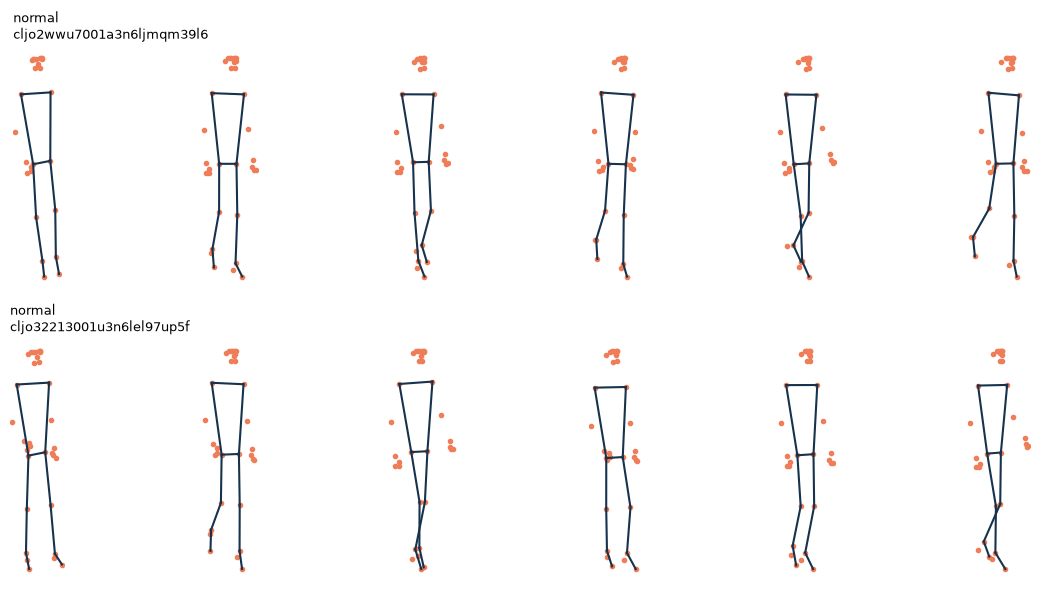

In [16]:
import matplotlib.pyplot as plt

STRIP_CONNECTIONS = [
    (11, 12), (11, 23), (12, 24), (23, 24),
    (23, 25), (25, 27), (27, 31),
    (24, 26), (26, 28), (28, 32),
]


def pose_strip(indices, columns=6):
    frame_indices = np.linspace(
        0, FRAMES - 1, columns, dtype=int
    )
    figure, axes = plt.subplots(
        len(indices), columns,
        figsize=(2.0 * columns, 3.0 * len(indices)),
        squeeze=False,
    )
    for row, sequence_index in enumerate(indices):
        for column, frame_index in enumerate(frame_indices):
            axis = axes[row, column]
            pose = all_xyz[sequence_index, frame_index]
            visible = all_valid[sequence_index, frame_index]
            for start, end in STRIP_CONNECTIONS:
                if visible[start] and visible[end]:
                    axis.plot(
                        [pose[start, 0], pose[end, 0]],
                        [pose[start, 1], pose[end, 1]],
                        color="#17324d",
                        linewidth=1.5,
                    )
            axis.scatter(
                pose[visible, 0], pose[visible, 1],
                s=9, color="#ef7d57",
            )
            axis.set_aspect("equal")
            axis.invert_yaxis()
            axis.axis("off")
            if column == 0:
                axis.set_title(
                    f"{labels[sequence_index]}\n{sequence_ids[sequence_index]}",
                    loc="left",
                    fontsize=9,
                )
    figure.tight_layout()
    plt.show()


pose_strip([query_index, int(neighbor_indices[0])])


**Before interpreting any close neighbour, check `source_video` first.** Two sequences from one YouTube upload can be similar because of framing, person identity, or background rather than gait. In the pair plotted above, the neighbour comes from the query's own source video, so its high cosine of 0.975 is not evidence about gait. This is the general rule for the whole project: the source video, not the sequence, is the independent unit of evidence.


## Step 9 of 9, Diagnostic 4: distance from the normal reference

**What we are about to do.** Build a normal centroid and a per-dimension normal scale from the 12 canonical normal embeddings, then measure how far every sequence sits from that centre in units of normal variability.

**Why a normal-referenced distance rather than another class metric.** Step 7 asked whether five classes separate from each other, and the answer was that they largely do not. This step asks a strictly easier and different question: does each condition group sit further from normal than normal does from itself? A one-dimensional, normal-anchored view can show ordering that a five-way partition cannot, and it matches how a screening question is usually posed.

**How the number is built, and why each part is there.** Subtract the normal mean, divide by the per-dimension normal standard deviation so that all 384 dimensions are measured in comparable units, take the Euclidean norm, and divide by the square root of 384 so the result does not simply grow with dimension count. Dimensions with near-zero normal spread are given a scale of 1 to avoid dividing by nothing.

**What to look at in the output.** The per-condition `mean` and `std` columns, read against the normal row rather than against zero. Normal itself does not sit at 0, because a sequence is compared with the centroid of a group it belongs to but is not identical to.

**What the output shows.** Normal sits at 0.986 with a spread of 0.177. Parkinson's is furthest at 2.955, then stroke at 2.192, then myopathic at 1.532, then cerebral palsy at 1.415. Every condition group's mean is above normal's, and the two smallest groups, Parkinson's at 9 sequences and stroke at 12, are the two furthest away.

**What we may conclude.** On this corpus, all four condition groups sit further from the normal centre than normal sequences do, and the ordering is stable enough to read. This is consistent with the representation carrying **some** abnormality-related information, which is a weaker and much easier claim than five-way separability.

**What we may not conclude.** Four things, and all of them matter.

1. This is **not** a calibrated anomaly score. It is a descriptive distance with no threshold, no calibration set, and no error rate attached.
2. It **cannot identify a condition**. Cerebral palsy at 1.415 and myopathic at 1.532 overlap heavily given their spreads, so a distance value does not name a group.
3. The normal reference is built from **one source video**, so "distance from normal" here is partly distance from one recording setting. The augmented normal cohort from notebook 04 is not in this canonical 96, so it cannot broaden the reference here.
4. It is transductive like everything else in this notebook. The encoder saw all 96 of these sequences and, from Stage 1, their labels.


In [17]:
normal_center = embeddings[labels == "normal"].mean(axis=0)
normal_scale = embeddings[labels == "normal"].std(axis=0)
normal_scale = np.where(normal_scale < 1e-6, 1.0, normal_scale)
standardized_distance = np.linalg.norm(
    (embeddings - normal_center) / normal_scale,
    axis=1,
) / np.sqrt(embeddings.shape[1])
distance_table = pd.DataFrame({
    "sequence_id": sequence_ids,
    "video_id": video_ids,
    "condition": labels,
    "normal_reference_distance": standardized_distance,
    "mode": MODE,
})
summary = (
    distance_table.groupby("condition")["normal_reference_distance"]
    .agg(["count", "mean", "std", "median"])
    .reindex(CONDITIONS)
)
display(summary)


,count,mean,std,median
condition,,,,
normal,12,0.985617,0.176507,1.034933
parkinsons,9,2.954832,0.297230,3.027561
stroke,12,2.192423,0.252670,2.199222
myopathic,47,1.532087,0.388482,1.572742
cerebralpalsy,16,1.414625,0.276869,1.408001


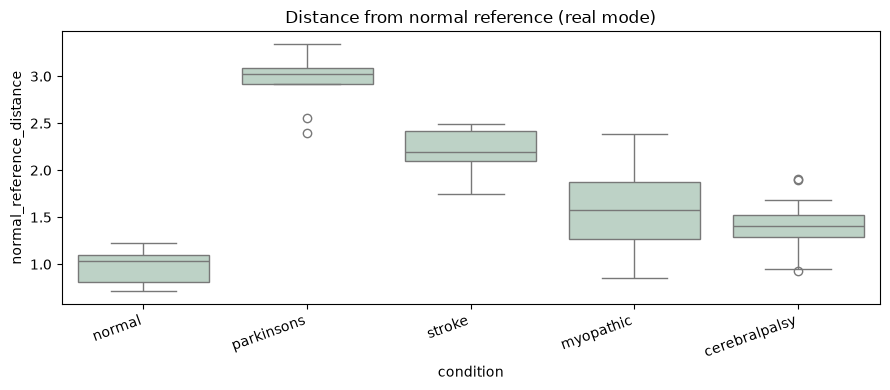

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 4))
sns.boxplot(
    data=distance_table,
    x="condition",
    y="normal_reference_distance",
    order=CONDITIONS,
    color="#b9d6c6",
)
plt.xticks(rotation=20, ha="right")
plt.title(f"Distance from normal reference ({MODE} mode)")
plt.tight_layout()


## Summary: what was established, what remains open, and how to fail this notebook

### Separate fatal failures from interpretation warnings

**Do not continue** to notebook 06 when any of these is true, because each is an implementation or representation failure rather than an inconvenient finding:

- the checkpoint is incomplete, or its stage order or cohort does not match;
- the mask differs from the 12 authorized indices;
- embeddings contain NaN or infinity;
- feature spread is near zero, or all vectors are nearly identical.

**The current saved real run fails none of these.** All 96 embeddings are finite, the mean within-condition cosine distance is 0.104 rather than 0, and notebook 04's final whole-corpus feature spread was 0.363 with a mean pairwise cosine of 0.660, neither at a collapse value. **The run did not collapse.**

The remaining checks are strong **interpretation warnings**. They are reasons to constrain what a score may be said to mean, not reasons to hide the downstream diagnostics:

- the smallest between-centroid distance is below the mean within-condition spread;
- neighbours and apparent groups may be explained by source-video identity;
- normal-anchor cosine falls substantially across later stages.

**The current saved real run triggers all three.** The minimum between-centroid cosine distance is **0.026** against a mean within-condition distance of **0.104**; the cosine silhouette is **0.054**; the top retrieved neighbours came from the query's own source video; and notebook 04's normal-anchor cosine fell to **0.617** by Stage 4. Notebook 06 may still run, and should, because it exposes confusion patterns, shortcut controls, and leakage. But its scores must not be presented as clean clustering or as independent performance.

### What this notebook established

1. **The pretext task was learned.** Predicted and teacher features agree at 0.553 mean token cosine with a standard deviation of 0.109.
2. **The run did not collapse.** Embeddings are finite and spread out, with within-condition cosine distances around 0.104 and a mean pairwise cosine of 0.660 rather than near 1.
3. **The five conditions do not cleanly separate.** Cosine silhouette 0.054, closest centroid pair 0.026 apart against 0.104 typical within-class spread.
4. **Retrieval is confounded by source video.** The two strongest neighbours of the example query were other excerpts from its own upload.
5. **All four condition groups sit further from the normal centre than normal does**, ordered Parkinson's 2.955, stroke 2.192, myopathic 1.532, cerebral palsy 1.415, against normal at 0.986. That supports a weak abnormality signal, not condition identification.

Points 2 and 3 are the pair to keep straight. Non-collapse is supported and class separation is not, and neither one implies anything about the other.

### What remains open

- Whether any of this survives a source-video split. Nothing in this notebook is held out, and 96 sequences from 18 videos is a small number of independent units.
- Whether the abnormality ordering in Step 9 is gait or detector behaviour. Stroke has the worst landmark coverage of any condition, at a minimum of 0.578, and this notebook does not control for that. Notebook 06 does, with a missingness-only classifier.
- What a representation trained without the label-aware group loss would look like. Because Stages 1 through 4 were label-informed, the weak geometry reported here is an upper bound on what a label-free run would show, not a neutral measurement.

### Next notebook

**06_capstone_health_condition_classifiers.ipynb** freezes this same target encoder and fits Random Forest readouts on it. Because the final encoder already saw every curriculum row and every condition annotation, those classifiers are **descriptive probes** with disclosed exposure, not held-out performance estimates. They would only become generalization estimates if the entire five-stage curriculum were retrained inside each outer source-video split. Carry Step 7's silhouette of 0.054 into that notebook: it is the reason a high descriptive accuracy there must not be read as clean condition separation.
